In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

L = 1.0  # длина балки (м)
EI = 1.0  # жесткость EI (произвольно, т.к. нормируем)
m = 0.1  # масса на конце


# Функция характеристического уравнения
def char_eq(k):
    if k == 0:
        return 1e6  # избегаем деления на 0
    return (np.cos(k * L) * np.cosh(k * L) + 1) + (m * k / EI) * (
                np.sin(k * L) * np.cosh(k * L) - np.sinh(k * L) * np.cos(k * L))


# Это начальные приближения для поиска корней характеристического уравнения — т.е. значений 
# 𝑘
# k, при которых удовлетворяется граничное условие на правом конце балки с грузом.
# Для балки без груза (свободный конец) собственные значения приближённо равны (2n-1)*pi/2
# В случае с концентрацией массы на конце, значения смещаются, но всё ещё примерно расположены в тех же интервалах.
k_guesses = [1.5, 4.5, 7.5, 10.5]

# который ищет нуль функции вблизи заданной точки. Но он находит только ближайший корень, поэтому:
# Каждое значение в k_guesses задаёт интервал, в котором мы надеемся найти очередной корень.
# Если взять слишком близкие точки — может вернуться один и тот же корень дважды.
# Если пропустить интервал — можем пропустить корень (т.е. одну из мод колебаний).
k_solutions = [fsolve(char_eq, guess)[0] for guess in k_guesses]

# Вычислим соответствующие собственные частоты
omega = [k ** 2 * np.sqrt(EI) for k in k_solutions]

omega


[np.float64(4.508909445171069),
 np.float64(4.508909445171069),
 np.float64(31.456409973124885),
 np.float64(87.53975688362638)]

<h1>Численное решение<h1>

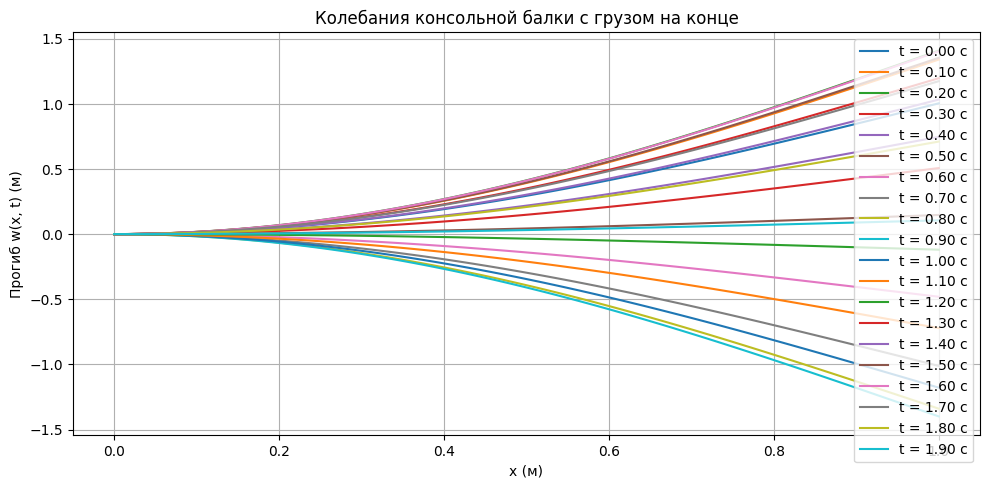

In [2]:
import numpy as np
import matplotlib.pyplot as plt

L = 1.0  # длина балки
EI = 1e4  # жесткость
m = 10.0  # масса грузика
g = 9.81
rho = 1.0  # плотность балки
A = 1.0  # площадь поперечного сечения
M = rho * A * L  # итоговая масса балки 
Meff = 0.236 * M  # эффективная масса балки в первой моде

omega_1 = 4.5  # нашел

t = np.linspace(0, 2, 500)

# Коэффициенты колебаний 
A1 = 1
B1 = 1


# Простая форма первой моды 
def phi1(x):
    return (1 - np.cos(np.pi * x / (2 * L)))  # простая приближенная форма


# Статический прогиб
def w_static(x):
    return (mg / (6 * EI)) * (-x ** 3 + 3 * L * x ** 2)


# Расчет колебаний 
X = np.linspace(0, L, 100)
T, Xgrid = np.meshgrid(t, X)
mg = m * g

# Статическа
W_stat = w_static(Xgrid)

# Динамическа
W_dyn = phi1(Xgrid) * (A1 * np.cos(omega_1 * T) + B1 * np.sin(omega_1 * T))

# Полное смещение
W = W_stat + W_dyn

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(0, len(t), 25):
    ax.plot(X, W[:, i], label=f't = {t[i]:.2f} c')

ax.set_title("Колебания консольной балки с грузом на конце")
ax.set_xlabel("x (м)")
ax.set_ylabel("Прогиб w(x, t) (м)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
